# Task
Train a CNN model on MNIST, implement FGSM to generate and visualize adversarial examples, and then implement and evaluate feature squeezing as a defense against these adversarial examples, visualizing its effect.

## Load and preprocess data

### Subtask:
Load the MNIST dataset and preprocess it for training the CNN model.


**Reasoning**:
Load the MNIST dataset, split it, normalize the pixel values, reshape the images, and one-hot encode the labels using TensorFlow/Keras.



In [14]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to include a channel dimension
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Convert labels to one-hot encoded vectors
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Create TensorFlow Datasets for efficient batching
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(128)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(128)

print("MNIST dataset loaded and preprocessed.")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

MNIST dataset loaded and preprocessed.
x_train shape: (60000, 28, 28, 1), y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1), y_test shape: (10000, 10)


## Build and train cnn model

### Subtask:
Build a simple CNN model and train it on the preprocessed MNIST data.


In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(train_dataset, epochs=5)

model.summary()

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8662 - loss: 0.4861
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9785 - loss: 0.0671
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9863 - loss: 0.0453
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9900 - loss: 0.0332
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0251


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

## Evaluate CNN Model

### Subtask:
Evaluate the trained CNN model on the test set to get a baseline accuracy.

In [16]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_dataset)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9843 - loss: 0.0455
Test loss: 0.0357
Test accuracy: 0.9875


Display a few images from the test set along with their true and predicted labels to visually demonstrate the model's performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


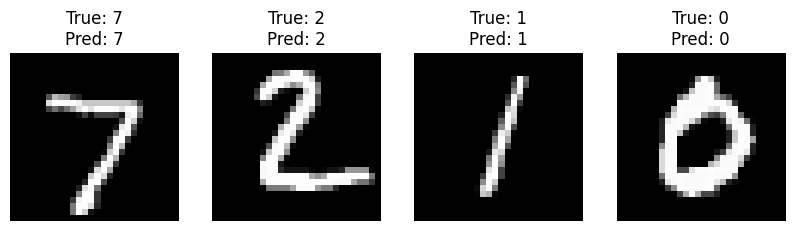

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get a few images from the test set
num_images_to_show = 4
sample_images = x_test[:num_images_to_show]
sample_labels = y_test[:num_images_to_show]

# Get the model's predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(sample_labels, axis=1)

# Display the images and their labels
plt.figure(figsize=(10, 4))
for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()

## Implement FGSM

### Subtask:
Implement the Fast Gradient Sign Method (FGSM) to generate adversarial examples.

Define a function to generate adversarial examples using the FGSM algorithm.

In [18]:
def create_adversarial_pattern(input_image, input_label):
    # Use TensorFlow's GradientTape to record operations for automatic differentiation
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = model(input_image)
        loss = tf.keras.losses.categorical_crossentropy(input_label, prediction)

    # Get the gradients of the loss with respect to the input image
    gradient = tape.gradient(loss, input_image)
    # Get the sign of the gradients to create the adversarial perturbation
    signed_grad = tf.sign(gradient)
    return signed_grad

## Generate and Visualize Adversarial Examples

### Subtask:
Generate adversarial examples using FGSM and visualize them along with the original images and their predicted labels to demonstrate how the adversarial examples fool the model.

Generate adversarial examples for a few test images using the FGSM function and visualize them alongside the original images and their predicted labels to show the impact of the adversarial perturbations.

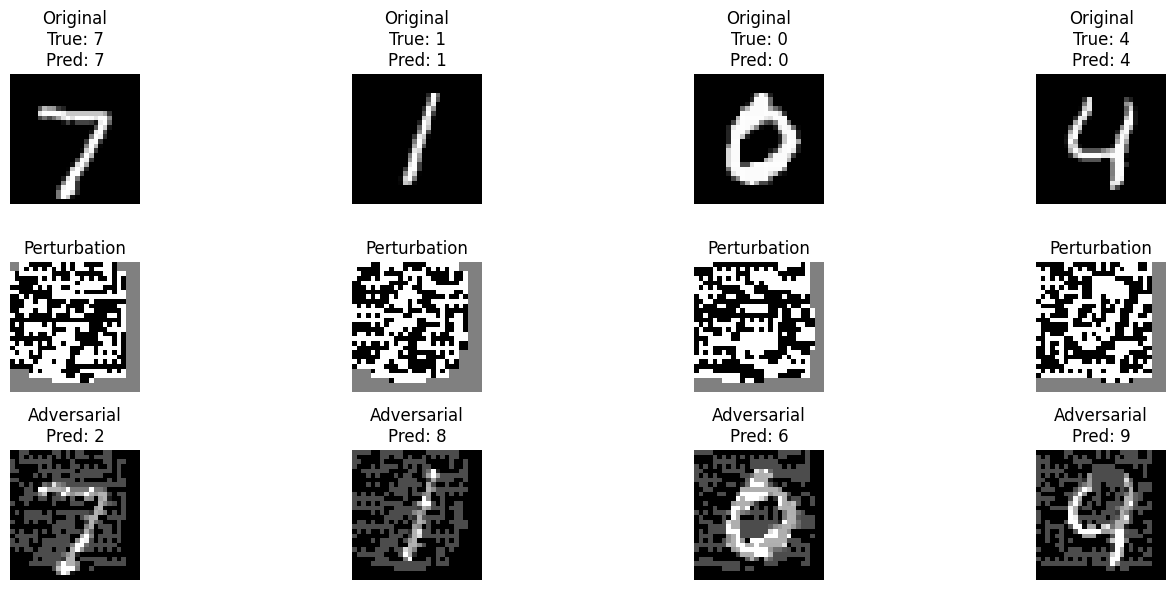

In [19]:
# Choose a few images from the test set to generate adversarial examples
num_images_to_check = 20 # Check more images to find misclassified adversarial examples
epsilon = 0.3 # Increased epsilon for visualization

successful_attacks = []

for i in range(num_images_to_check):
    sample_image_attack = x_test[i:i+1]
    sample_label_attack = y_test[i:i+1]

    # Convert to TensorFlow Tensors
    sample_image_attack_tensor = tf.convert_to_tensor(sample_image_attack)
    sample_label_attack_tensor = tf.convert_to_tensor(sample_label_attack)

    # Generate adversarial example
    perturbations = create_adversarial_pattern(sample_image_attack_tensor, sample_label_attack_tensor)
    adversarial_image = sample_image_attack_tensor + epsilon * perturbations
    adversarial_image = tf.clip_by_value(adversarial_image, 0, 1) # Clip to maintain valid pixel values

    # Get predictions for original and adversarial images
    original_prediction = np.argmax(model.predict(sample_image_attack, verbose=0), axis=1)[0]
    adversarial_prediction = np.argmax(model.predict(adversarial_image, verbose=0), axis=1)[0]
    true_label = np.argmax(sample_label_attack, axis=1)[0]

    # Check if the adversarial attack was successful (misclassification)
    if original_prediction == true_label and adversarial_prediction != true_label:
        successful_attacks.append({
            'original_image': sample_image_attack[0],
            'perturbation': perturbations[0].numpy(),
            'adversarial_image': adversarial_image[0].numpy(),
            'true_label': true_label,
            'original_prediction': original_prediction,
            'adversarial_prediction': adversarial_prediction
        })

# Visualize successful adversarial examples
num_successful_attacks_to_show = min(4, len(successful_attacks)) # Show up to 4 successful attacks

if num_successful_attacks_to_show > 0:
    plt.figure(figsize=(15, 6))
    for i in range(num_successful_attacks_to_show):
        attack_info = successful_attacks[i]

        # Original Image
        plt.subplot(3, num_successful_attacks_to_show, i + 1)
        plt.imshow(attack_info['original_image'].squeeze(), cmap='gray')
        plt.title(f"Original\nTrue: {attack_info['true_label']}\nPred: {attack_info['original_prediction']}")
        plt.axis('off')

        # Perturbation
        plt.subplot(3, num_successful_attacks_to_show, i + num_successful_attacks_to_show + 1)
        plt.imshow(attack_info['perturbation'].squeeze(), cmap='gray')
        plt.title("Perturbation")
        plt.axis('off')

        # Adversarial Image
        plt.subplot(3, num_successful_attacks_to_show, i + 2 * num_successful_attacks_to_show + 1)
        plt.imshow(attack_info['adversarial_image'].squeeze(), cmap='gray')
        plt.title(f"Adversarial\nPred: {attack_info['adversarial_prediction']}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No successful adversarial attacks found among the first {num_images_to_check} test images with epsilon={epsilon}.")

## Evaluate Model on Adversarial Examples

### Subtask:
Evaluate the trained CNN model on the generated adversarial examples to show the drop in accuracy.

In [20]:
# Generate adversarial examples for the entire test dataset
# We will iterate through the test dataset in batches

adversarial_test_images = []
true_test_labels = []

# Set epsilon for generating adversarial examples
epsilon = 0.3 # Increased epsilon for a stronger attack

for images, labels in test_dataset:
    # Generate adversarial patterns for the batch
    perturbations = create_adversarial_pattern(images, labels)
    # Apply perturbation to create adversarial images
    adv_images = images + epsilon * perturbations
    # Clip the adversarial images to maintain valid pixel values
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    adversarial_test_images.append(adv_images)
    true_test_labels.append(labels)

# Concatenate the batches to form the full adversarial test dataset
adversarial_test_images = tf.concat(adversarial_test_images, axis=0)
true_test_labels = tf.concat(true_test_labels, axis=0)

# Create a TensorFlow Dataset for the adversarial test data
adversarial_test_dataset = tf.data.Dataset.from_tensor_slices((adversarial_test_images, true_test_labels)).batch(128)


# Evaluate the model on the adversarial test dataset
loss_adversarial, accuracy_adversarial = model.evaluate(adversarial_test_dataset)

print(f"Adversarial Test loss: {loss_adversarial:.4f}")
print(f"Adversarial Test accuracy: {accuracy_adversarial:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1112 - loss: 4.5473
Adversarial Test loss: 4.3023
Adversarial Test accuracy: 0.1355


## Evaluate Model with Feature Squeezing on Adversarial Examples

### Subtask:
Evaluate the model with the feature squeezing defense on the adversarial examples to demonstrate its effectiveness in detecting them.

## Implement Feature Squeezing

### Subtask:
Implement the feature squeezing defense mechanism.

Implement the feature squeezing defense by defining functions to reduce color depth and spatial smoothing.

In [21]:
import cv2 # Using OpenCV for spatial smoothing
import numpy as np
import tensorflow as tf


def color_squeezing(x, bit_depth=5):
    """Reduce the color depth of an image."""
    x = x * (2**bit_depth - 1)
    x = np.round(x)
    x = x / (2**bit_depth - 1)
    return x

def spatial_smoothing(x, kernel_size=(2, 2)):
    """Apply spatial smoothing to an image."""
    # Ensure the input is in the correct format for OpenCV (height, width, channels)
    # OpenCV expects shape (height, width) for grayscale or (height, width, channels) for color
    # Our input is (batch_size, height, width, channels)

    # We need to apply smoothing to each image in the batch
    squeezed_images = []
    for img in x:
        if img.shape[-1] == 1: # Grayscale image (shape needs to be (height, width))
            img_gray = img.squeeze() # Remove channel dimension for OpenCV
            img_smoothed = cv2.boxFilter((img_gray * 255).astype(np.uint8), -1, kernel_size)
            img_smoothed = img_smoothed.astype(np.float32) / 255.0
            img_smoothed = img_smoothed[..., tf.newaxis] # Add channel dimension back
        else: # Color image (assuming 3 channels)
            img_bgr = (img * 255).astype(np.uint8)
            img_smoothed = cv2.boxFilter(img_bgr, -1, kernel_size)
            img_smoothed = img_smoothed.astype(np.float32) / 255.0
        squeezed_images.append(img_smoothed)

    # Stack the processed images back into a batch
    return np.stack(squeezed_images, axis=0)


def feature_squeezing(x, bit_depth=5, kernel_size=(2, 2)):
    """Apply feature squeezing (color squeezing and spatial smoothing)."""
    x_squeezed = color_squeezing(x, bit_depth)
    x_squeezed = spatial_smoothing(x_squeezed, kernel_size)
    return x_squeezed

## Evaluate Model with Feature Squeezing on Adversarial Examples

### Subtask:
Evaluate the model with the feature squeezing defense on the adversarial examples to demonstrate its effectiveness in detecting them.

Check the shape of the squeezed adversarial images to ensure it is compatible with the model's input shape.

In [22]:
# Apply feature squeezing to the adversarial test images
adversarial_test_images_squeezed = feature_squeezing(adversarial_test_images.numpy())

# Create a TensorFlow Dataset for the squeezed adversarial test data
adversarial_test_dataset_squeezed = tf.data.Dataset.from_tensor_slices((adversarial_test_images_squeezed, true_test_labels)).batch(128)

# Evaluate the model on the squeezed adversarial test dataset
loss_adversarial_squeezed, accuracy_adversarial_squeezed = model.evaluate(adversarial_test_dataset_squeezed)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2535 - loss: 2.9928


In [23]:
print(f"Shape of original adversarial images: {adversarial_test_images.shape}")
print(f"Shape of squeezed adversarial images: {adversarial_test_images_squeezed.shape}")

Shape of original adversarial images: (10000, 28, 28, 1)
Shape of squeezed adversarial images: (10000, 28, 28, 1)


## Evaluate Model with Feature Squeezing on Adversarial Examples

### Subtask:
Evaluate the model with the feature squeezing defense on the adversarial examples to demonstrate its effectiveness in detecting them.

**Reasoning**:
Apply feature squeezing to the adversarial test set and evaluate the model's accuracy on these squeezed adversarial examples.

In [24]:
# Apply feature squeezing to the adversarial test images
adversarial_test_images_squeezed = feature_squeezing(adversarial_test_images.numpy())

# Create a TensorFlow Dataset for the squeezed adversarial test data
adversarial_test_dataset_squeezed = tf.data.Dataset.from_tensor_slices((adversarial_test_images_squeezed, true_test_labels)).batch(128)

# Evaluate the model on the squeezed adversarial test dataset
loss_adversarial_squeezed, accuracy_adversarial_squeezed = model.evaluate(adversarial_test_dataset_squeezed)

print(f"Adversarial Test loss (Squeezed): {loss_adversarial_squeezed:.4f}")
print(f"Adversarial Test accuracy (Squeezed): {accuracy_adversarial_squeezed:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2535 - loss: 2.9928
Adversarial Test loss (Squeezed): 2.7896
Adversarial Test accuracy (Squeezed): 0.2893


## Visualize Feature Squeezing Effect

### Subtask:
Visualize the effect of feature squeezing on adversarial examples compared to clean examples.

Select a few clean and adversarial examples, apply feature squeezing to them, and visualize the original, squeezed, adversarial, and squeezed adversarial images to demonstrate the visual impact of the defense.

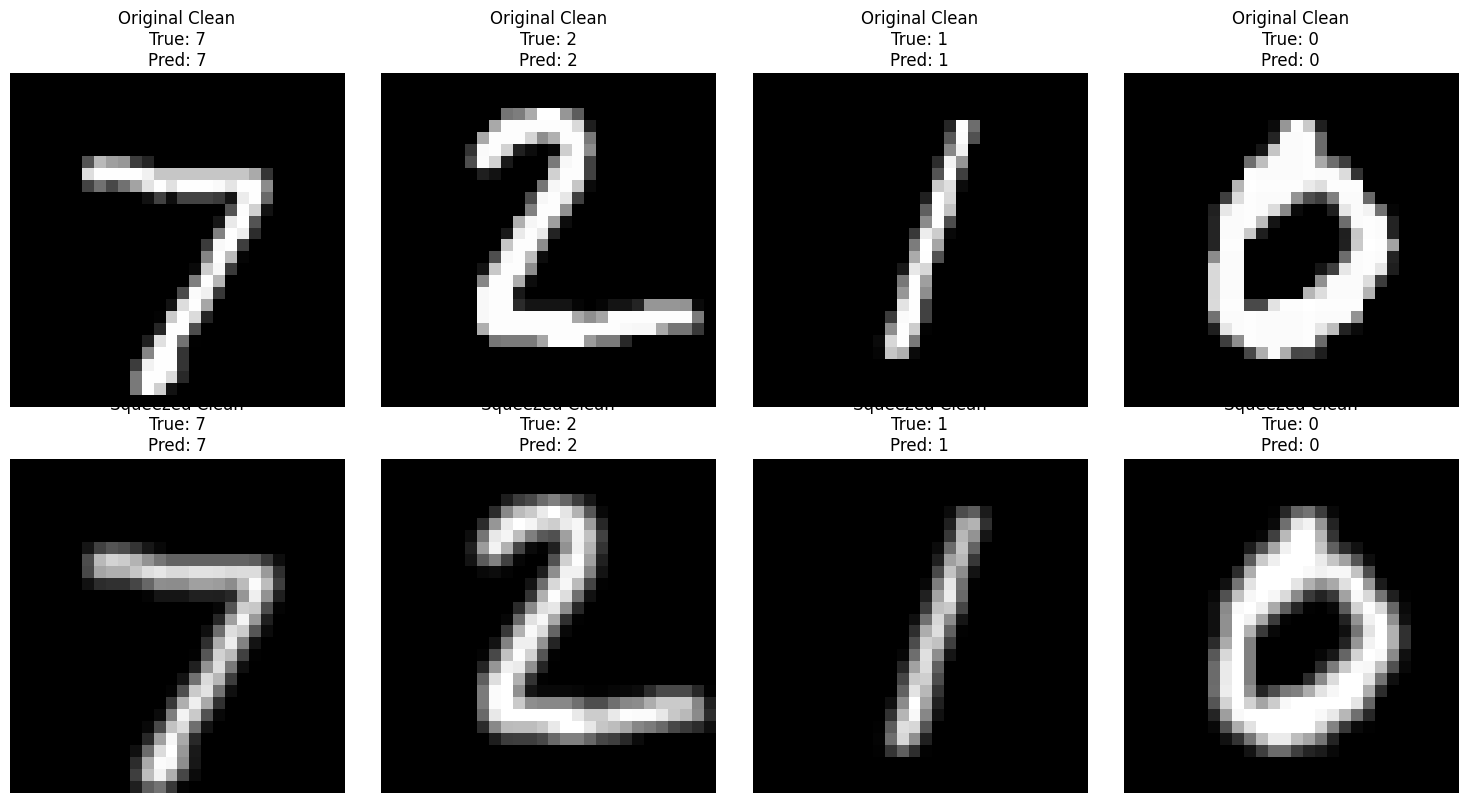

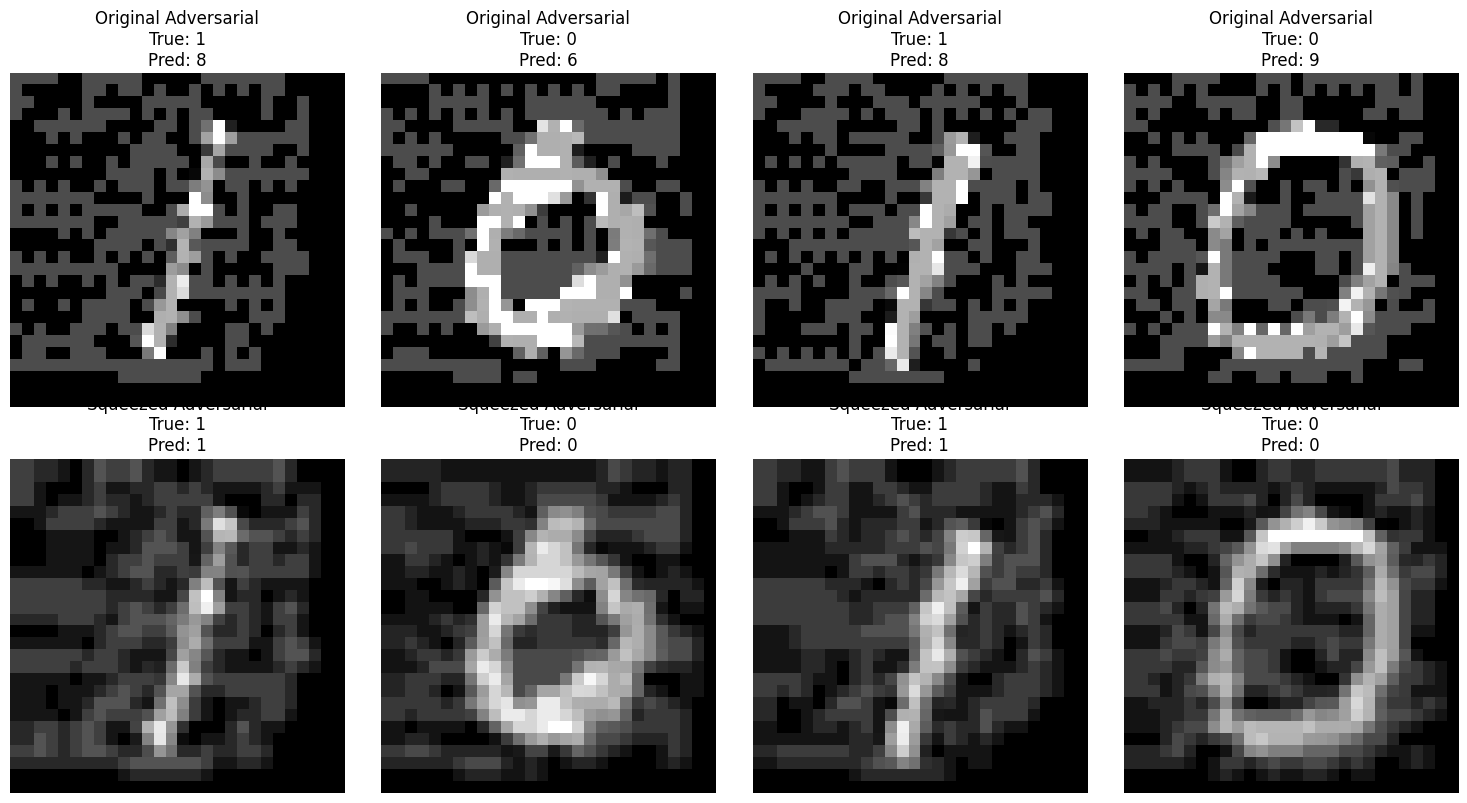

In [25]:
# Choose a few images to visualize the squeezing effect
num_images_to_visualize = 4
num_adversarial_to_check = 20 # Check more adversarial examples to find successful squeezing cases

# Get original clean and adversarial images
sample_clean_images = x_test[:num_images_to_visualize]
sample_adversarial_images_pool = adversarial_test_images[:num_adversarial_to_check].numpy() # Pool of adversarial images to check

# Apply feature squeezing to clean images
sample_clean_images_squeezed = feature_squeezing(sample_clean_images)

# Get predictions for original and squeezed clean images
predictions_clean_original = np.argmax(model.predict(sample_clean_images, verbose=0), axis=1)
predictions_clean_squeezed = np.argmax(model.predict(sample_clean_images_squeezed, verbose=0), axis=1)

# Get true labels for the visualized samples (both clean and adversarial pool)
true_labels_visualize_clean = np.argmax(y_test[:num_images_to_visualize], axis=1)
true_labels_adversarial_pool = np.argmax(y_test[:num_adversarial_to_check], axis=1)


# Visualize the clean images
plt.figure(figsize=(15, 8))

for i in range(num_images_to_visualize):
    # Original Clean
    plt.subplot(2, num_images_to_visualize, i + 1)
    plt.imshow(sample_clean_images[i].squeeze(), cmap='gray')
    plt.title(f"Original Clean\nTrue: {true_labels_visualize_clean[i]}\nPred: {predictions_clean_original[i]}")
    plt.axis('off')

    # Squeezed Clean
    plt.subplot(2, num_images_to_visualize, i + num_images_to_visualize + 1)
    plt.imshow(sample_clean_images_squeezed[i].squeeze(), cmap='gray')
    plt.title(f"Squeezed Clean\nTrue: {true_labels_visualize_clean[i]}\nPred: {predictions_clean_squeezed[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Filter for adversarial examples where squeezing leads to a correct prediction
successful_squeezing_examples = []
for i in range(num_adversarial_to_check):
    original_adversarial_image = sample_adversarial_images_pool[i][np.newaxis, ...] # Add batch dim
    true_label = true_labels_adversarial_pool[i]

    # Apply feature squeezing
    squeezed_adversarial_image = feature_squeezing(original_adversarial_image)[0] # Remove batch dim after squeezing

    # Get predictions
    original_adversarial_pred = np.argmax(model.predict(original_adversarial_image, verbose=0), axis=1)[0]
    squeezed_adversarial_pred = np.argmax(model.predict(squeezed_adversarial_image[np.newaxis, ...], verbose=0), axis=1)[0] # Add batch dim for prediction


    # Check if original adversarial was misclassified AND squeezed adversarial is correctly classified
    if original_adversarial_pred != true_label and squeezed_adversarial_pred == true_label:
         successful_squeezing_examples.append({
            'original_adversarial': original_adversarial_image[0], # Remove batch dim for storage
            'squeezed_adversarial': squeezed_adversarial_image,
            'true_label': true_label,
            'original_adversarial_pred': original_adversarial_pred,
            'squeezed_adversarial_pred': squeezed_adversarial_pred
        })

# Visualize the adversarial images where squeezing was successful (up to num_images_to_visualize)
num_successful_squeezing_to_show = min(num_images_to_visualize, len(successful_squeezing_examples))

if num_successful_squeezing_to_show > 0:
    plt.figure(figsize=(15, 8))
    for i in range(num_successful_squeezing_to_show):
        example_info = successful_squeezing_examples[i]

        # Original Adversarial
        plt.subplot(2, num_successful_squeezing_to_show, i + 1)
        plt.imshow(example_info['original_adversarial'].squeeze(), cmap='gray')
        plt.title(f"Original Adversarial\nTrue: {example_info['true_label']}\nPred: {example_info['original_adversarial_pred']}")
        plt.axis('off')

        # Squeezed Adversarial
        plt.subplot(2, num_successful_squeezing_to_show, i + num_successful_squeezing_to_show + 1)
        plt.imshow(example_info['squeezed_adversarial'].squeeze(), cmap='gray')
        plt.title(f"Squeezed Adversarial\nTrue: {example_info['true_label']}\nPred: {example_info['squeezed_adversarial_pred']}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No adversarial examples among the first {num_adversarial_to_check} where squeezing led to a correct prediction.")